# technique notes - LSTM and TFT

Dr Talebi's second first-step is to get familiar with the main techniques before the real experiments.
So this notebook is me working through the two models I'll actually use:

1. LSTM (the baseline) - Hochreiter & Schmidhuber 1997
2. Temporal Fusion Transformer - Lim et al. 2021

Small demos only, everything runs on CPU. The proper training happens in notebooks 02 and 03.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)
print(torch.__version__)

2.10.0+cpu


## 1. LSTM basics

A vanilla RNN squashes everything through one hidden state and gradients vanish over long sequences.
The LSTM fixes this with a separate cell state c_t and three gates that control what flows through it:

- forget gate: how much of the old cell state to keep
- input gate: how much of the new candidate to write
- output gate: how much of the cell state to expose as the hidden state

All three gates are sigmoids (0 to 1), so they act like soft switches. The cell state update is
mostly additive which is why gradients survive much longer than in a plain RNN.

In [2]:
# doing one LSTM cell step by hand with numpy just to see the moving parts
# sizes: input dim 3, hidden dim 4

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

d_in, d_h = 3, 4
rng = np.random.default_rng(0)

x_t = rng.normal(size=(d_in,))          # input at time t
h_prev = np.zeros(d_h)                  # previous hidden state
c_prev = np.zeros(d_h)                  # previous cell state

# one weight matrix per gate (ignoring biases to keep it readable)
W_f = rng.normal(size=(d_h, d_in + d_h))
W_i = rng.normal(size=(d_h, d_in + d_h))
W_o = rng.normal(size=(d_h, d_in + d_h))
W_c = rng.normal(size=(d_h, d_in + d_h))

z = np.concatenate([x_t, h_prev])

f_t = sigmoid(W_f @ z)            # forget gate
i_t = sigmoid(W_i @ z)            # input gate
o_t = sigmoid(W_o @ z)            # output gate
c_tilde = np.tanh(W_c @ z)        # candidate cell state

c_t = f_t * c_prev + i_t * c_tilde
h_t = o_t * np.tanh(c_t)

print('forget gate:', f_t.round(3))
print('input gate: ', i_t.round(3))
print('new cell:   ', c_t.round(3))
print('new hidden: ', h_t.round(3))

forget gate: [0.578 0.172 0.64  0.407]
input gate:  [0.584 0.288 0.736 0.287]
new cell:    [ 0.51  -0.001 -0.364 -0.174]
new hidden:  [ 0.148 -0.    -0.083 -0.08 ]


## 2. a tiny LSTM forecaster on real data

Now the same idea but with pytorch on actual Jena temperatures. Setup mirrors the real project
(168h history in, 24h forecast out) but on a small slice so it trains in a minute or two on CPU.

In [3]:
# load just jena
if os.path.exists('/kaggle/input'):
    DATA_PATH = '/kaggle/input/multi-city-weather-2000-2009/'
else:
    DATA_PATH = 'D:/Final year project/Dataset/'

jena = pd.read_csv(DATA_PATH + 'jena_germany_2000_2009_hourly.csv', skiprows=3, low_memory=False)
jena.columns = [c.split(' (')[0] for c in jena.columns]
jena['time'] = pd.to_datetime(jena['time'])
temp = jena.set_index('time')['temperature_2m']
temp.shape

(87672,)

In [4]:
# train on 2000-2003, test on 2004. only using the temperature itself, univariate
train_s = temp['2000':'2003']
test_s = temp['2004']

mu, sd = train_s.mean(), train_s.std()
print(f'train mean {mu:.2f} C, std {sd:.2f}')

def make_windows(series, n_in=168, n_out=24, stride=24):
    vals = ((series - mu) / sd).values.astype(np.float32)
    X, y = [], []
    for i in range(0, len(vals) - n_in - n_out, stride):
        X.append(vals[i:i + n_in])
        y.append(vals[i + n_in:i + n_in + n_out])
    return torch.tensor(np.array(X)).unsqueeze(-1), torch.tensor(np.array(y))

X_train, y_train = make_windows(train_s)
X_test, y_test = make_windows(test_s)
print('train windows:', X_train.shape, 'test windows:', X_test.shape)

train mean 10.09 C, std 7.96
train windows: torch.Size([1453, 168, 1]) test windows: torch.Size([358, 168, 1])


In [5]:
class TinyLSTM(nn.Module):
    def __init__(self, hidden=32, horizon=24):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])   # last hidden state -> 24 values

model = TinyLSTM()
sum(p.numel() for p in model.parameters())

5272

In [6]:
# training loop, nothing fancy
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.L1Loss()   # MAE, same metric as the main experiments

batch = 64
losses = []
for epoch in range(8):
    perm = torch.randperm(len(X_train))
    ep_loss = 0.0
    for i in range(0, len(X_train), batch):
        idx = perm[i:i + batch]
        opt.zero_grad()
        pred = model(X_train[idx])
        loss = loss_fn(pred, y_train[idx])
        loss.backward()
        opt.step()
        ep_loss += loss.item() * len(idx)
    ep_loss /= len(X_train)
    losses.append(ep_loss)
    print(f'epoch {epoch + 1}: train MAE {ep_loss * sd:.3f} C')

epoch 1: train MAE 6.396 C


epoch 2: train MAE 5.226 C


epoch 3: train MAE 3.336 C


epoch 4: train MAE 2.461 C


epoch 5: train MAE 2.045 C


epoch 6: train MAE 1.907 C


epoch 7: train MAE 1.857 C


epoch 8: train MAE 1.828 C


In [7]:
# evaluate on 2004 and compare against persistence (just repeat the last 24h)
model.eval()
with torch.no_grad():
    pred = model(X_test)

mae_lstm = (pred - y_test).abs().mean().item() * sd
naive = X_test[:, -24:, 0]
mae_naive = (naive - y_test).abs().mean().item() * sd

print(f'tiny LSTM MAE:    {mae_lstm:.2f} C')
print(f'persistence MAE:  {mae_naive:.2f} C')
# full model in notebook 02 gets ~1.4 C with all features and more training, this is just a toy

tiny LSTM MAE:    1.68 C
persistence MAE:  2.06 C


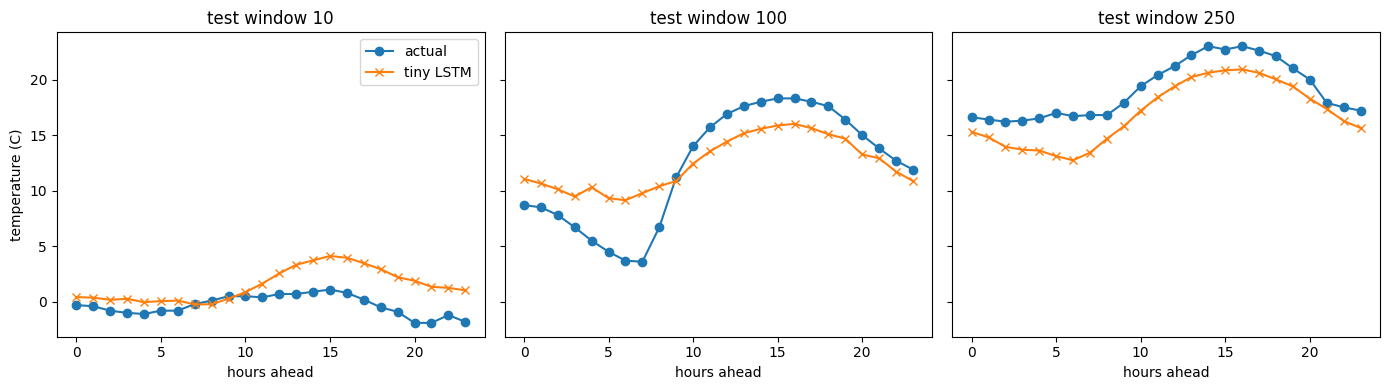

In [8]:
# look at a few example forecasts
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, k in zip(axes, [10, 100, 250]):
    ax.plot(range(24), y_test[k] * sd + mu, marker='o', label='actual')
    ax.plot(range(24), pred[k] * sd + mu, marker='x', label='tiny LSTM')
    ax.set_xlabel('hours ahead')
    ax.set_title(f'test window {k}')
axes[0].set_ylabel('temperature (C)')
axes[0].legend()
plt.tight_layout()
plt.show()

things I noticed playing with this:

- even a 32-unit univariate LSTM beats persistence comfortably
- the forecasts smooth out the daily cycle but miss sharper swings, which is where the
  extra weather covariates (radiation, humidity, pressure) should help
- MAE in standardised units needs multiplying back by the std to be in degrees, easy to forget

## 3. Temporal Fusion Transformer

The TFT (Lim et al. 2021) is the main model of the project. It is not one idea but a stack of them:

- **variable selection networks** - learn a weight per input variable at each timestep, so the model
  itself says which features matter (this is the built-in interpretability used for RQ3)
- **gated residual networks (GRNs)** - building block everywhere, lets the network skip any
  nonlinear processing it doesn't need
- **LSTM encoder-decoder** - handles local/sequential patterns (so the LSTM baseline lives inside the TFT)
- **multi-head attention** over the encoder - lets the decoder look directly at any past timestep,
  e.g. the same hour yesterday, instead of squeezing it all through the hidden state
- **quantile outputs** - predicts the 10th/50th/90th percentile instead of a single number

The two pieces worth understanding properly are the quantile loss and the attention, so small
demos of each below.

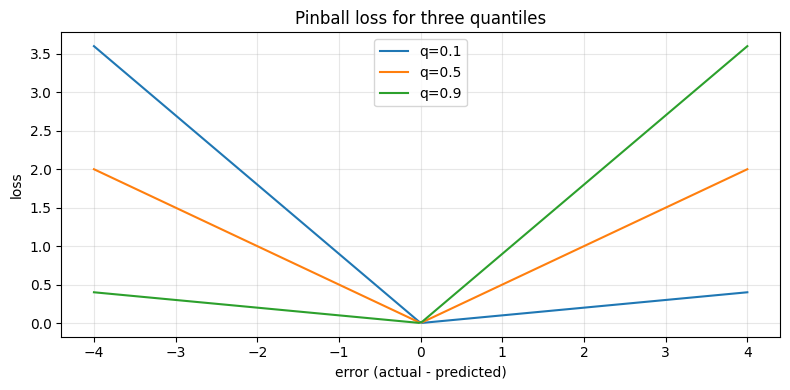

In [9]:
# quantile (pinball) loss. asymmetric: under-predicting is punished differently to over-predicting
def pinball(error, q):
    return np.maximum(q * error, (q - 1) * error)

err = np.linspace(-4, 4, 200)
fig, ax = plt.subplots(figsize=(8, 4))
for q in [0.1, 0.5, 0.9]:
    ax.plot(err, pinball(err, q), label=f'q={q}')
ax.set_xlabel('error (actual - predicted)')
ax.set_ylabel('loss')
ax.set_title('Pinball loss for three quantiles')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# q=0.9 punishes under-prediction 9x harder than over-prediction, which pushes that
# output up until only ~10% of actuals land above it. that is the whole trick.

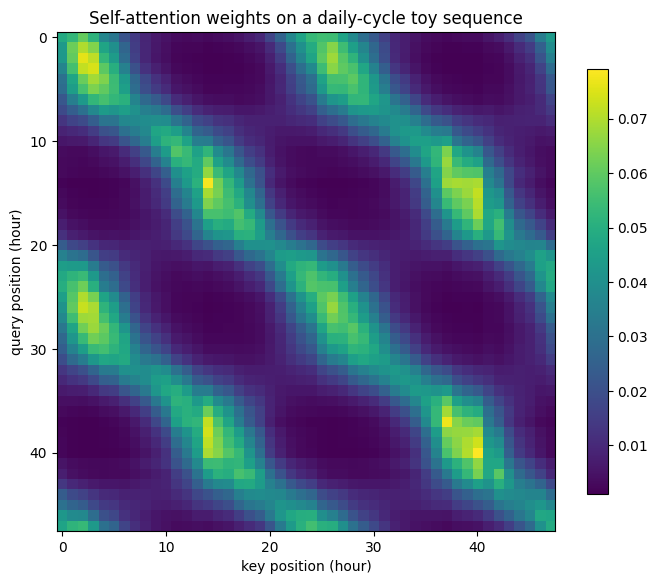

In [10]:
# scaled dot product attention on a toy sequence, the core op inside the TFT
def attention(Q, K, V):
    scores = Q @ K.T / np.sqrt(Q.shape[-1])
    w = np.exp(scores - scores.max(axis=-1, keepdims=True))
    w = w / w.sum(axis=-1, keepdims=True)
    return w @ V, w

# fake encoder of 48 hourly steps with a daily sine pattern, 8-dim embeddings
rng = np.random.default_rng(3)
t = np.arange(48)
emb = np.stack([np.sin(2 * np.pi * (t + p) / 24) for p in range(8)], axis=1)
emb += rng.normal(scale=0.1, size=emb.shape)

out, w = attention(emb, emb, emb)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(w, cmap='viridis')
ax.set_xlabel('key position (hour)')
ax.set_ylabel('query position (hour)')
ax.set_title('Self-attention weights on a daily-cycle toy sequence')
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

# diagonal stripes 24 apart: each hour attends to the same hour on other days.
# this is exactly the long range pattern an LSTM struggles to keep in one hidden vector

## 4. takeaways

- LSTM: gated additive memory, good local pattern model, single point forecast unless modified
- TFT: LSTM inside + attention for long range + variable selection for interpretability + quantiles
  for uncertainty. more moving parts, more capacity, but needs more tuning (which probably explains
  why my first TFT run lost to the LSTM, 1.53 vs 1.39 MAE)
- the quantile outputs give intervals but they are not guaranteed calibrated -> conformal prediction
  on top (notebook 08)

reading list:
- Hochreiter & Schmidhuber (1997) Long Short-Term Memory
- Lim et al. (2021) Temporal Fusion Transformers for interpretable multi-horizon time series forecasting
- Vaswani et al. (2017) Attention Is All You Need
- Montero-Manso & Hyndman (2021) on local vs global models, for the per-city vs pooled question

TODO: read the TFT paper section on static covariate encoders again, still a bit fuzzy on how
city identity gets injected